In [162]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Реализация Дерева решений

In [ ]:
class Node:
    def __init__(self, feature, threshold, left, right, value):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class DecisionTreeClassifier:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
    
    def gini(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)
    
    def information_gain(self, y, y_left, y_right):
        impurity = self.gini(y)
        impurity_left = self.gini(y_left)
        impurity_right = self.gini(y_right)
        
        n = len(y)
        n_left = len(y_left)
        n_right = len(y_right)
        
        gain = impurity - (n_left/n * impurity_left + n_right/n * impurity_right)
        return gain
    
    def best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None
        
        n_samples, n_features = X.shape
        
        for feature_idx in range(n_features):
            # Получаем уникальные значения признака
            feature_values = np.unique(X[:, feature_idx])
            
            # Перебираем возможные пороги
            for i in range(len(feature_values) - 1):
                threshold = (feature_values[i] + feature_values[i + 1]) / 2
                
                # Разделяем данные
                left_mask = X[:, feature_idx] <= threshold
                right_mask = X[:, feature_idx] > threshold
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                # Пропускаем если разделение не удовлетворяет минимальному количеству samples
                if len(y_left) < self.min_samples_split or len(y_right) < self.min_samples_split:
                    continue
                
                # Вычисляем прирост информации
                gain = self.information_gain(y, y_left, y_right, self.criterion)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_gain

    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        
        # Критерии остановки
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            len(np.unique(y)) == 1):
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)
        
        # Находим лучшее разделение
        feature, threshold, gain = self.best_split(X, y)
        
        # Если не нашли хорошего разделения, создаем лист
        if feature is None:
            leaf_value = self.most_common_label(y)
            return Node(value=leaf_value)

        # Разделяем данные
        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold
        
        # Рекурсивно строим левое и правое поддеревья
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(feature=feature, threshold=threshold, 
                   left=left_subtree, right=right_subtree)

    def most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        self.root = self.build_tree(X, y)
    
    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
        return np.array([self.traverse_tree(x, self.root) for x in X])
    
    def traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.traverse_tree(x, node.left)
        else:
            return self.traverse_tree(x, node.right)

# Предобработка данных

In [164]:
df = pd.read_csv('data/online_gaming_behavior_dataset.csv')
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [165]:
df.isna().sum() # Пропуски

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [166]:
df.drop(['PlayerID'], axis=1, inplace=True)

In [167]:
df['is_male'] = df['Gender'].apply(lambda s: 1 if s == 'Male' else 0).astype(bool)
df.drop(['Gender'], axis=1, inplace=True)

In [168]:
df['GameDifficulty'] = df['GameDifficulty'].apply(lambda s: {
    'Easy': 1, 
    'Medium': 2, 
    'Hard': 3
}[s]).astype(np.int8)

In [169]:
df['EngagementLevel'] = df['EngagementLevel'].apply(lambda s: {
    'Low': 1, 
    'Medium': 2, 
    'High': 3
}[s]).astype(np.int8)

In [170]:
df = pd.get_dummies(df) # One-Hot

In [171]:
df.dtypes

Age                            int64
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                  int8
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel                 int8
is_male                         bool
Location_Asia                   bool
Location_Europe                 bool
Location_Other                  bool
Location_USA                    bool
GameGenre_Action                bool
GameGenre_RPG                   bool
GameGenre_Simulation            bool
GameGenre_Sports                bool
GameGenre_Strategy              bool
dtype: object

**Корреляция**

[]

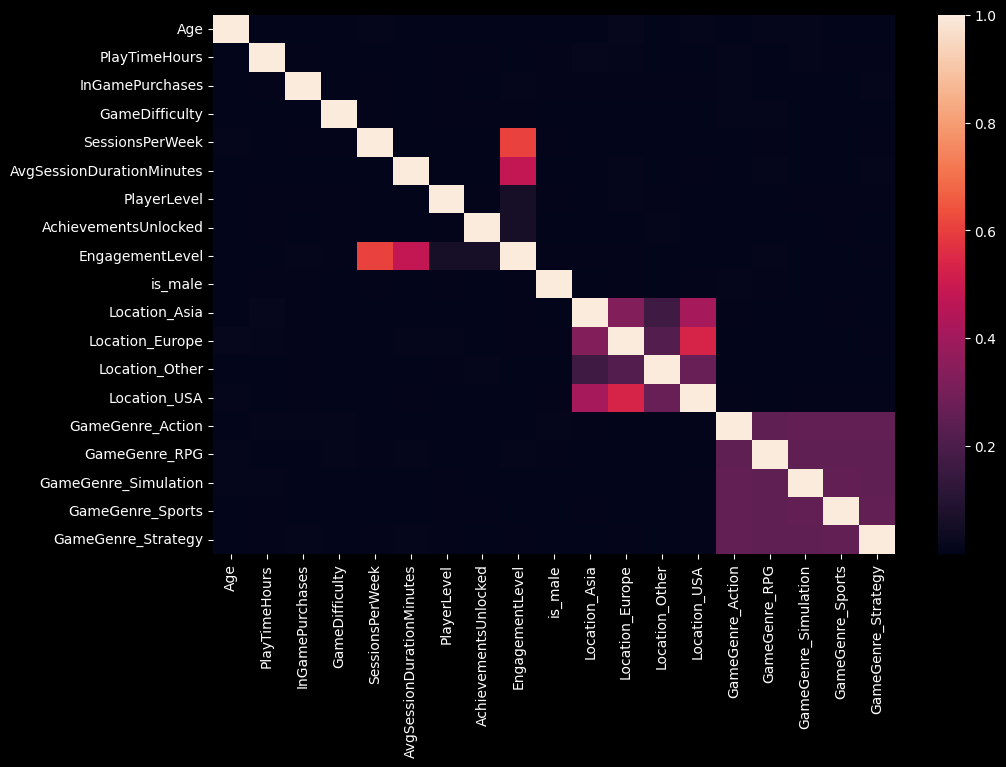

In [172]:
import seaborn as sns

plt.figure(figsize=(11, 7))
sns.heatmap(np.abs(df.corr()))
plt.plot()

In [173]:
target = 'EngagementLevel'

**Удаляем колонки с преступно низкой корреляцией**

In [174]:
for col in df.columns: 
    val = df[col].corr(df[target])
    if np.abs(val) < 0.01: 
        print(f'target - {col}: {val}')
        df.drop([col], axis=1, inplace=True)

target - Age: 0.000824314634022478
target - PlayTimeHours: -0.0018494887007830774
target - InGamePurchases: 0.008209390780614348
target - GameDifficulty: 0.005057317006155766
target - is_male: -0.0049780903564931546
target - Location_Asia: 0.00610973436329742
target - Location_Europe: -0.005964679419349942
target - Location_Other: -0.0031744671667248677
target - Location_USA: 0.002499017563214939
target - GameGenre_Action: 0.00022483579148506328
target - GameGenre_RPG: -0.00970737076970998
target - GameGenre_Simulation: 0.0011841648742697188
target - GameGenre_Sports: 0.0005715522927771923
target - GameGenre_Strategy: 0.007699823255260666


[]

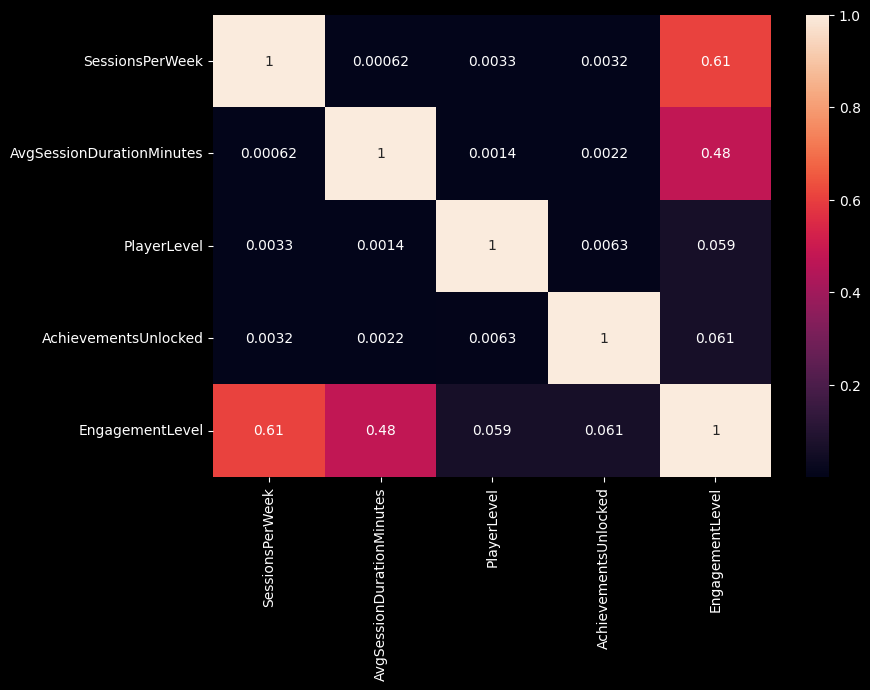

In [175]:
plt.figure(figsize=(9, 6))
sns.heatmap(np.abs(df.corr()), annot=True)
plt.plot()

**Скейлинг и разбиение данных**

In [176]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


SEED = 42

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Применение Дерева решений

# Моя реализация

In [177]:
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [198]:
def plot_and_save_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.plot()

Accuracy: 0.8491
Precision: 0.8518


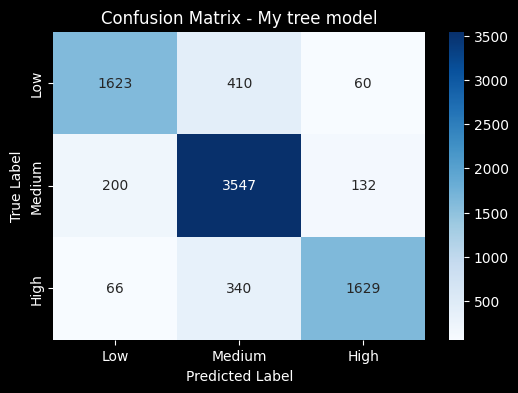

In [199]:
my_tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, criterion='gini')
my_tree.fit(X_train, y_train)

y_pred = my_tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")

plot_and_save_confusion_matrix(y_test, y_pred, 'My tree model')

## Реализация из sklearn

Train accuracy: 0.925688
Train precision: 0.925948

Test accuracy: 0.897090
Test precision: 0.897120


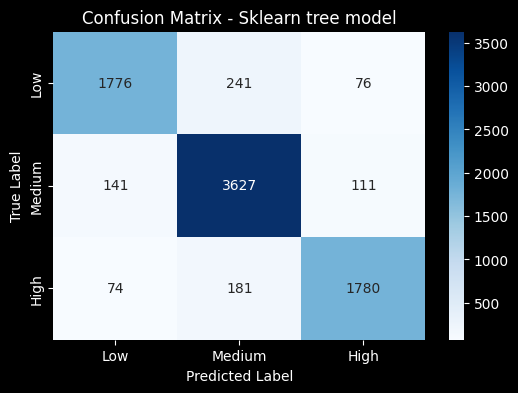

In [200]:
from sklearn.tree import DecisionTreeClassifier as SkLinearClassifier


sk_model = SkLinearClassifier(max_depth=10, random_state=SEED)
sk_model.fit(X_train_scaled, y_train)

# Метрики на тренировочных данных
y_pred_train = sk_model.predict(X_train_scaled)
acc_train = accuracy_score(y_train, y_pred_train)
prec_train = precision_score(y_train, y_pred_train, average='weighted')

print(f"Train accuracy: {acc_train:.6f}")
print(f"Train precision: {prec_train:.6f}")
print()

# Метрики на тестовых данных
y_pred_test = sk_model.predict(X_test_scaled)
acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted')

print(f"Test accuracy: {acc_test:.6f}")
print(f"Test precision: {prec_test:.6f}")

plot_and_save_confusion_matrix(y_test, y_pred_test, 'Sklearn tree model')

## Использование иных готовых моделей

In [204]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


Random Forest:
  Train accuracy: 0.931932
  Train precision:  0.932160

  Test accuracy:  0.916573
  Test precision:   0.916711

Gradient Boosting:
  Train accuracy: 0.901177
  Train precision:  0.901716

  Test accuracy:  0.897090
  Test precision:   0.897487


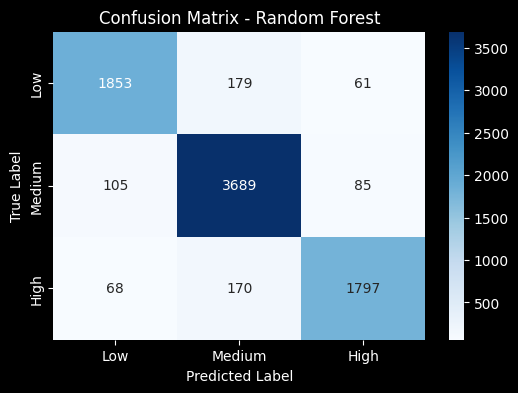

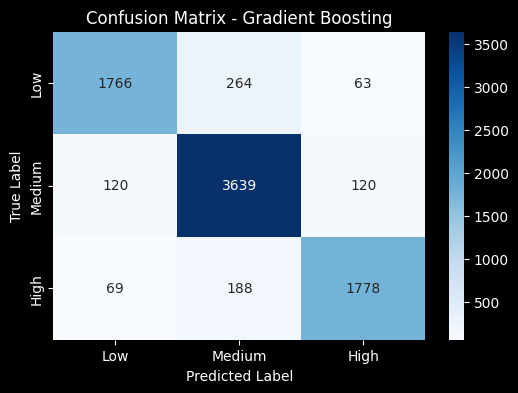

In [208]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=SEED),
}

results = {
    'Model': [],
    'Train accuracy': [],
    'Test accuracy': [],
    'Train precision': [],
    'Test precision': []
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    test_precision = precision_score(y_test, y_test_pred, average='weighted')

    results['Model'].append(name)
    results['Train accuracy'].append(train_accuracy)
    results['Test accuracy'].append(test_accuracy)
    results['Train precision'].append(train_precision)
    results['Test precision'].append(test_precision)

    print(f"\n{name}:")
    print(f"  Train accuracy: {train_accuracy:.6f}")
    print(f"  Train precision:  {train_precision:.6f}\n")
    print(f"  Test accuracy:  {test_accuracy:.6f}")
    print(f"  Test precision:   {test_precision:.6f}")

    plot_and_save_confusion_matrix(y_test, y_test_pred, name)

results_df = pd.DataFrame(results)

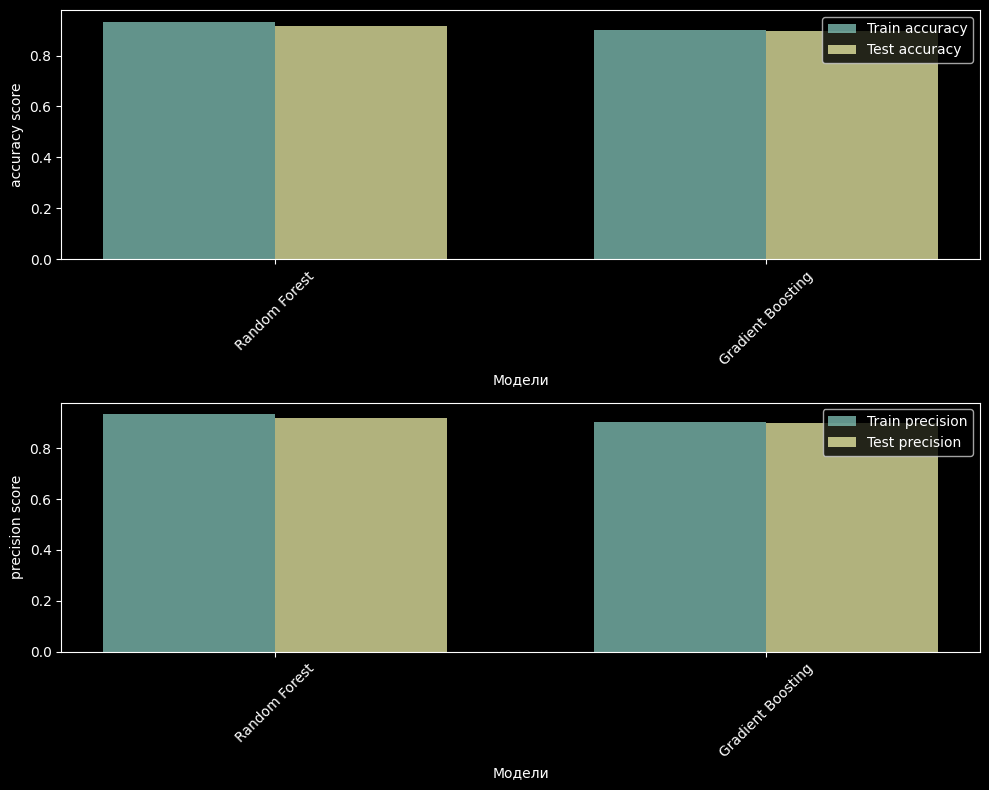

In [214]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)

x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Train accuracy'], width, label='Train accuracy', alpha=0.7)
plt.bar(x_pos + width/2, results_df['Test accuracy'], width, label='Test accuracy', alpha=0.7)

plt.xlabel('Модели')
plt.ylabel('accuracy score')

plt.xticks(x_pos, results_df['Model'], rotation=45)
plt.legend()

plt.subplot(2, 1, 2)

plt.bar(x_pos - width/2, results_df['Train precision'], width, label='Train precision', alpha=0.7)
plt.bar(x_pos + width/2, results_df['Test precision'], width, label='Test precision', alpha=0.7)

plt.xlabel('Модели')
plt.ylabel('precision score')

plt.xticks(x_pos, results_df['Model'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()